# Практическая работа 3 Построение ML-пайплайна в Spark MLlib
Бочков Андрей  
Вариант 3  
## Цель работы
Построить сквозной ML-пайплайн на больших данных с использованием Spark MLlib для задачи классификации пола пользователя (`gender`) по характеристикам тренировки.
## Постановка задачи
Для варианта 3:
1. Создать признаки:
   - длина массива пульса (`hr_length`);
   - средняя скорость (`avg_speed`);
2. Обучить модель классификации `DecisionTreeClassifier`
3. Оценить качество модели по метрике ROC-AUC
4. Определить, какой признак важнее для определения пола: скорость или выносливость

In [1]:
import os
import warnings

warnings.filterwarnings("ignore")

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
from pyspark.sql.functions import col, size

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Импорты успешно загружены")

Импорты успешно загружены


In [2]:
DATA_PATH = "/home/devops/lab03/data/endomondoHR.json"
SCREEN_DIR = "/home/devops/lab03/screenshots"

os.makedirs(SCREEN_DIR, exist_ok=True)

print("DATA_PATH =", DATA_PATH)
print("SCREEN_DIR =", SCREEN_DIR)
print("Файл существует:", os.path.exists(DATA_PATH))

DATA_PATH = /home/devops/lab03/data/endomondoHR.json
SCREEN_DIR = /home/devops/lab03/screenshots
Файл существует: True


In [3]:
spark = (
    SparkSession.builder
    .appName("Lab03_Var3_Gender_Classification")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

print("Spark version:", spark.version)
print("Spark app name:", spark.sparkContext.appName)

26/03/28 11:59:41 WARN Utils: Your hostname, devopsvm resolves to a loopback address: 127.0.1.1; using 10.0.2.15 instead (on interface enp0s3)
26/03/28 11:59:41 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/28 11:59:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 3.5.3
Spark app name: Lab03_Var3_Gender_Classification


In [4]:
raw_df = spark.read.json(DATA_PATH)

print("Количество сырых записей:", raw_df.count())
raw_df.printSchema()
raw_df.show(3, truncate=False)

Количество сырых записей: 253020
root
 |-- altitude: array (nullable = true)
 |    |-- element: double (containsNull = true)
 |-- gender: string (nullable = true)
 |-- heart_rate: array (nullable = true)
 |    |-- element: long (containsNull = true)
 |-- id: long (nullable = true)
 |-- latitude: array (nullable = true)
 |    |-- element: double (containsNull = true)
 |-- longitude: array (nullable = true)
 |    |-- element: double (containsNull = true)
 |-- speed: array (nullable = true)
 |    |-- element: double (containsNull = true)
 |-- sport: string (nullable = true)
 |-- timestamp: array (nullable = true)
 |    |-- element: long (containsNull = true)
 |-- url: string (nullable = true)
 |-- userId: long (nullable = true)

+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [5]:
raw_df.select("gender", "sport", "heart_rate", "speed").show(5, truncate=False)

+------+----------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [6]:
key_cols = ["gender", "sport", "heart_rate", "speed"]

total_rows = raw_df.count()
print("Всего строк:", total_rows)

for c in key_cols:
    null_count = raw_df.filter(F.col(c).isNull()).count()
    print(f"{c}: null = {null_count} ({null_count / total_rows * 100:.2f}%)")

Всего строк: 253020


gender: null = 0 (0.00%)


sport: null = 0 (0.00%)


heart_rate: null = 0 (0.00%)


speed: null = 203360 (80.37%)


In [7]:
raw_df.groupBy("gender").count().orderBy(F.desc("count")).show(truncate=False)

+-------+------+
|gender |count |
+-------+------+
|male   |235119|
|female |15959 |
|unknown|1942  |
+-------+------+



In [8]:
raw_df.select(
    F.size("heart_rate").alias("heart_rate_len"),
    F.size("speed").alias("speed_len")
).show(10, truncate=False)

+--------------+---------+
|heart_rate_len|speed_len|
+--------------+---------+
|500           |500      |
|500           |500      |
|500           |500      |
|500           |500      |
|500           |-1       |
|500           |-1       |
|500           |500      |
|500           |500      |
|500           |-1       |
|500           |500      |
+--------------+---------+
only showing top 10 rows



In [9]:
raw_df.select(
    "gender",
    "sport",
    F.size("heart_rate").alias("hr_len"),
    F.size("speed").alias("speed_len")
).show(10, truncate=False)

+------+----------------+------+---------+
|gender|sport           |hr_len|speed_len|
+------+----------------+------+---------+
|male  |bike            |500   |500      |
|male  |bike            |500   |500      |
|male  |bike            |500   |500      |
|male  |bike            |500   |500      |
|male  |bike (transport)|500   |-1       |
|male  |bike (transport)|500   |-1       |
|male  |bike (transport)|500   |500      |
|male  |bike (transport)|500   |500      |
|male  |bike            |500   |-1       |
|male  |bike            |500   |500      |
+------+----------------+------+---------+
only showing top 10 rows



In [10]:
df_clean = (
    raw_df
    .filter(F.col("gender").isin("male", "female"))
    .filter(F.size("heart_rate") > 0)
    .filter(F.col("speed").isNotNull())
    .filter(F.size("speed") > 0)
)

raw_count = raw_df.count()
clean_count = df_clean.count()

print(f"Строк до очистки: {raw_count}")
print(f"Строк после очистки: {clean_count}")
print(f"Осталось: {clean_count / raw_count * 100:.2f}% от исходных данных")

Строк до очистки: 253020
Строк после очистки: 49455
Осталось: 19.55% от исходных данных


In [11]:
df_clean.groupBy("gender").count().orderBy(F.desc("count")).show()

+------+-----+
|gender|count|
+------+-----+
|  male|45976|
|female| 3479|
+------+-----+



In [12]:
df_clean.select(
    "gender",
    "sport",
    F.size("heart_rate").alias("hr_len"),
    F.size("speed").alias("speed_len")
).show(10, truncate=False)

+------+----------------+------+---------+
|gender|sport           |hr_len|speed_len|
+------+----------------+------+---------+
|male  |bike            |500   |500      |
|male  |bike            |500   |500      |
|male  |bike            |500   |500      |
|male  |bike            |500   |500      |
|male  |bike (transport)|500   |500      |
|male  |bike (transport)|500   |500      |
|male  |bike            |500   |500      |
|male  |bike            |500   |500      |
|male  |bike            |500   |500      |
|male  |bike            |500   |500      |
+------+----------------+------+---------+
only showing top 10 rows



In [13]:
df_features = df_clean.select(
    "gender",
    F.size("heart_rate").cast("double").alias("hr_length"),
    (
        F.aggregate(
            "speed",
            F.lit(0.0),
            lambda acc, x: acc + x.cast("double")
        ) / F.size("speed")
    ).alias("avg_speed")
)

print("Количество строк в df_features:", df_features.count())
df_features.show(10, truncate=False)

Количество строк в df_features: 49455
+------+---------+------------------+
|gender|hr_length|avg_speed         |
+------+---------+------------------+
|male  |500.0    |26.162157600000004|
|male  |500.0    |27.218368800000004|
|male  |500.0    |26.050773600000017|
|male  |500.0    |26.87783759999997 |
|male  |500.0    |29.592280800000022|
|male  |500.0    |21.67317359999999 |
|male  |500.0    |27.497556000000028|
|male  |500.0    |25.193404799999993|
|male  |500.0    |27.228132000000024|
|male  |500.0    |24.542733599999988|
+------+---------+------------------+
only showing top 10 rows



In [14]:
df_features.select(
    F.min("hr_length").alias("min_hr_length"),
    F.max("hr_length").alias("max_hr_length"),
    F.min("avg_speed").alias("min_avg_speed"),
    F.max("avg_speed").alias("max_avg_speed")
).show()

+-------------+-------------+-------------+-------------+
|min_hr_length|max_hr_length|min_avg_speed|max_avg_speed|
+-------------+-------------+-------------+-------------+
|          1.0|        500.0|          0.0|      114.678|
+-------------+-------------+-------------+-------------+



In [15]:
df_features.groupBy("gender").agg(
    F.avg("hr_length").alias("avg_hr_length"),
    F.avg("avg_speed").alias("avg_avg_speed")
).show()

+------+-----------------+------------------+
|gender|    avg_hr_length|     avg_avg_speed|
+------+-----------------+------------------+
|female|421.9735556194309|13.819771488884339|
|  male|430.8197972855403|19.352239951946956|
+------+-----------------+------------------+



In [16]:
label_indexer = StringIndexer(
    inputCol="gender",
    outputCol="label",
    handleInvalid="skip"
)

assembler = VectorAssembler(
    inputCols=["hr_length", "avg_speed"],
    outputCol="features"
)

dt = DecisionTreeClassifier(
    labelCol="label",
    featuresCol="features",
    maxDepth=5,
    seed=42
)

pipeline = Pipeline(stages=[label_indexer, assembler, dt])

print("Pipeline успешно сконфигурирован")

Pipeline успешно сконфигурирован


In [17]:
train_df, test_df = df_features.randomSplit([0.8, 0.2], seed=42)

print("Train rows:", train_df.count())
print("Test rows:", test_df.count())

Train rows: 39593


Test rows: 9862


In [18]:
model = pipeline.fit(train_df)
print("Модель успешно обучена")

Модель успешно обучена


In [19]:
predictions = model.transform(test_df)

predictions.select(
    "gender",
    "label",
    "hr_length",
    "avg_speed",
    "features",
    "prediction",
    "probability"
).show(10, truncate=False)

+------+-----+---------+------------------+--------------------------+----------+--------------------------------------+
|gender|label|hr_length|avg_speed         |features                  |prediction|probability                           |
+------+-----+---------+------------------+--------------------------+----------+--------------------------------------+
|female|1.0  |62.0     |10.526454859677424|[62.0,10.526454859677424] |0.0       |[0.93034122193317,0.06965877806682999]|
|female|1.0  |90.0     |7.206599999999999 |[90.0,7.206599999999999]  |0.0       |[0.93034122193317,0.06965877806682999]|
|female|1.0  |156.0    |11.011338461538456|[156.0,11.011338461538456]|0.0       |[0.93034122193317,0.06965877806682999]|
|female|1.0  |215.0    |8.398532093023253 |[215.0,8.398532093023253] |0.0       |[0.93034122193317,0.06965877806682999]|
|female|1.0  |267.0    |9.30333033707865  |[267.0,9.30333033707865]  |0.0       |[0.93034122193317,0.06965877806682999]|
|female|1.0  |284.0    |25.71638

In [20]:
roc_eval = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

acc_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

f1_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

roc_auc = roc_eval.evaluate(predictions)
accuracy = acc_eval.evaluate(predictions)
f1_score = f1_eval.evaluate(predictions)

print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"Accuracy : {accuracy:.4f}")
print(f"F1-score : {f1_score:.4f}")

ROC-AUC  : 0.5000
Accuracy : 0.9269
F1-score : 0.8917


In [21]:
predictions.groupBy("gender", "prediction").count().orderBy("gender", "prediction").show()

+------+----------+-----+
|gender|prediction|count|
+------+----------+-----+
|female|       0.0|  721|
|  male|       0.0| 9141|
+------+----------+-----+



In [22]:
pred_pd = predictions.select("label", "prediction").toPandas()

cm = pd.crosstab(
    pred_pd["label"],
    pred_pd["prediction"],
    rownames=["Actual"],
    colnames=["Predicted"]
)

cm

Predicted,0.0
Actual,
0.0,9141
1.0,721


In [23]:
label_model = model.stages[0]

print("Порядок меток в StringIndexer:")
print(label_model.labels)

Порядок меток в StringIndexer:
['male', 'female']


In [24]:
dt_model = model.stages[-1]

importances = dt_model.featureImportances.toArray()

feature_names = ["hr_length", "avg_speed"]

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df

,feature,importance
0,hr_length,0.0
1,avg_speed,0.0


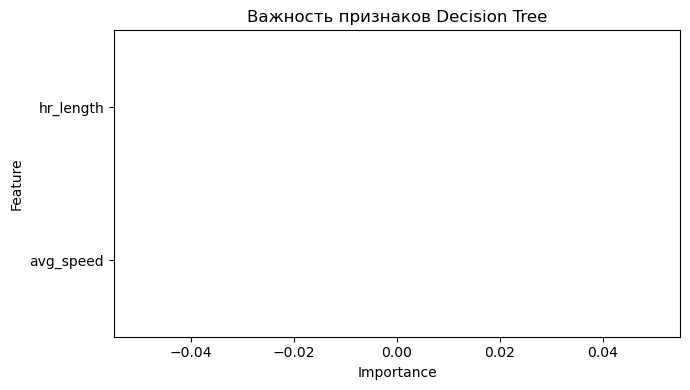

In [25]:

plt.figure(figsize=(7, 4))
sns.barplot(data=importance_df, x="importance", y="feature", palette="viridis")
plt.title("Важность признаков Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [26]:
train_male = train_df.filter(F.col("gender") == "male")
train_female = train_df.filter(F.col("gender") == "female")

female_count = train_female.count()
male_count = train_male.count()

sample_fraction = female_count / male_count

train_male_balanced = train_male.sample(withReplacement=False, fraction=sample_fraction, seed=42)
train_balanced = train_male_balanced.union(train_female)

print("Train male original   :", male_count)
print("Train female original :", female_count)
print("Sample fraction       :", sample_fraction)
print("Train balanced total  :", train_balanced.count())

train_balanced.groupBy("gender").count().show()

Train male original   : 36835
Train female original : 2758
Sample fraction       : 0.07487444007058504


Train balanced total  : 5459


+------+-----+
|gender|count|
+------+-----+
|  male| 2701|
|female| 2758|
+------+-----+



In [27]:
model_balanced = pipeline.fit(train_balanced)
print("Сбалансированная модель обучена")

Сбалансированная модель обучена


In [28]:
pred_balanced = model_balanced.transform(test_df)

roc_auc_bal = roc_eval.evaluate(pred_balanced)
accuracy_bal = acc_eval.evaluate(pred_balanced)
f1_bal = f1_eval.evaluate(pred_balanced)

print(f"Balanced ROC-AUC  : {roc_auc_bal:.4f}")
print(f"Balanced Accuracy : {accuracy_bal:.4f}")
print(f"Balanced F1-score : {f1_bal:.4f}")

Balanced ROC-AUC  : 0.6409
Balanced Accuracy : 0.7907
Balanced F1-score : 0.8332


In [29]:
dt_model_bal = model_balanced.stages[-1]

importances_bal = dt_model_bal.featureImportances.toArray()

importance_bal_df = pd.DataFrame({
    "feature": ["hr_length", "avg_speed"],
    "importance": importances_bal
}).sort_values("importance", ascending=False)

importance_bal_df

,feature,importance
1,avg_speed,0.944598
0,hr_length,0.055402


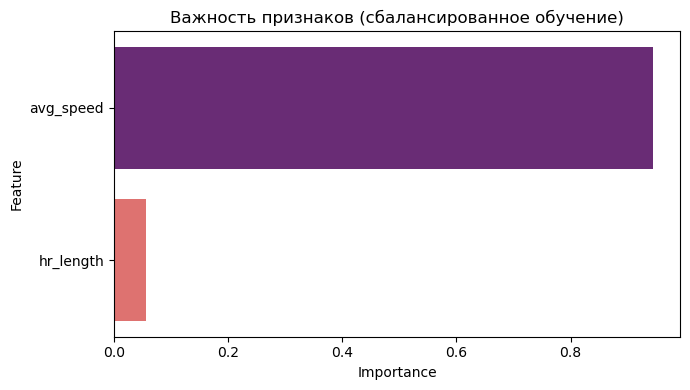

In [30]:
plt.figure(figsize=(7, 4))
sns.barplot(data=importance_bal_df, x="importance", y="feature", palette="magma")
plt.title("Важность признаков (сбалансированное обучение)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [31]:
metrics_df = pd.DataFrame({
    "model": ["baseline", "balanced_train"],
    "roc_auc": [roc_auc, roc_auc_bal],
    "accuracy": [accuracy, accuracy_bal],
    "f1_score": [f1_score, f1_bal]
})

metrics_df

,model,roc_auc,accuracy,f1_score
0,baseline,0.500000,0.926891,0.891724
1,balanced_train,0.640934,0.790712,0.833217


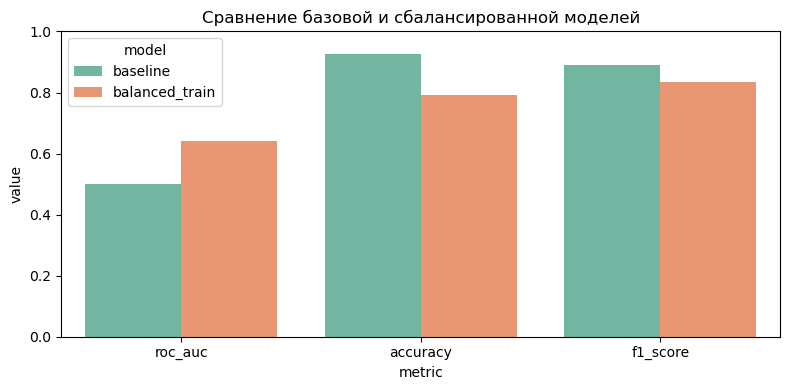

In [32]:
metrics_plot = metrics_df.melt(id_vars="model", var_name="metric", value_name="value")

plt.figure(figsize=(8, 4))
sns.barplot(data=metrics_plot, x="metric", y="value", hue="model", palette="Set2")
plt.title("Сравнение базовой и сбалансированной моделей")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Интерпретация результатов
Базовая модель на несбалансированной выборке выродилась в предсказание только доминирующего класса (`male`), что привело к формально высокой Accuracy, но низкой диагностической ценности модели. Это подтверждается значением ROC-AUC = 0.50, что соответствует случайному классификатору.

После балансировки обучающей выборки качество модели улучшилось: ROC-AUC вырос до 0.6409. Несмотря на снижение Accuracy, сбалансированная модель стала лучше различать классы и может использоваться для интерпретации влияния признаков.

Наиболее важным признаком оказалась средняя скорость (`avg_speed`), на которую пришлось около 94% суммарной важности. Признак длины массива пульса (`hr_length`), использованный как прокси выносливости/длительности тренировки, дал существенно меньший вклад - около 6%.

### Ответ на вопрос варианта
Для определения пола пользователя в данной модели более важным признаком является **скорость**, а не **выносливость**.

### Бизнес-вывод
Полученный результат показывает, что различия между пользователями по полу в данном наборе тренировочных данных сильнее проявляются в интенсивности движения, чем в продолжительности записи пульса. Это может быть полезно для сегментации пользователей, персонализации тренировочных рекомендаций и таргетированных маркетинговых предложений в fitness продуктах.